# Notebook: qr_rectify_gui.py Step-by-step (mit Zwischenoutputs)

Ziel:
1) Bild wählen und anzeigen (Original)
2) ROI-Vorschläge (C2F) + gelbe Patch-Boxen
3) Patches extrahieren + CNN Inference (p)
4) Thresholding (thr=0.95) → Positive Patches
5) IoU-Merge (iou=0.3) → Merged ROIs
6) ROI-Crop + Plan A (OpenCV corners)
7) Plan B V4 (otsu, k=3, close=4, open=0) mit Zwischenausgaben
8) Quad → Warp → optional decode-check
9) Zusammenfassung über Top-N ROIs

## Setup: Imports, Repo-Root finden, Script als Modul laden
Diese Zelle stellt die Umgebung für das Notebook her:

- **Imports**: Lädt alle zentralen Bibliotheken (OpenCV, NumPy, Matplotlib). Zusätzlich werden optionale Pakete (`pandas`, `torch`, `ipywidgets`) per `try/except` eingebunden, damit das Notebook auch ohne diese Pakete starten kann.
- **Repo-Root Erkennung**: `find_repo_root()` läuft vom aktuellen Notebook-Pfad nach oben, bis ein Ordner gefunden wird, der typisch für dein Projekt ist (enthält `scripts/` und `src/`). So bleiben Pfade stabil, egal von wo das Notebook gestartet wird.
- **Script dynamisch importieren**: `qr_rectify_gui.py` wird mit `importlib` als Modul geladen.
- **Wichtig: Python 3.13 / dataclass Fix**: `sys.modules[spec.name] = qr` registriert das Modul vor `exec_module`. Das verhindert den bekannten `dataclasses`-Fehler, der sonst beim Dekorieren von `@dataclass` auftreten kann.

Output: Repo-Root, Script-Pfad und Modulname als Bestätigung.

In [1]:
from __future__ import annotations

from pathlib import Path
import importlib.util
import sys
import math
import json

import cv2
import numpy as np
import matplotlib.pyplot as plt

# Optional libs
try:
    import pandas as pd
except Exception:
    pd = None

try:
    import torch
except Exception:
    torch = None

try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
except Exception:
    widgets = None
    display = None
    clear_output = None


def find_repo_root(start: Path | None = None) -> Path:
    p = (start or Path.cwd()).resolve()
    for _ in range(12):
        if (p / "scripts").exists() and (p / "src").exists():
            return p
        p = p.parent
    return Path.cwd().resolve()


REPO_ROOT = find_repo_root()
SCRIPT_PATH = REPO_ROOT / "scripts" / "qr_rectify_gui.py"
assert SCRIPT_PATH.exists(), f"Script nicht gefunden: {SCRIPT_PATH}"

spec = importlib.util.spec_from_file_location("qr_rectify_gui", str(SCRIPT_PATH))
assert spec is not None and spec.loader is not None, "Konnte spec/loader nicht erstellen."

qr = importlib.util.module_from_spec(spec)

# >>> WICHTIG (Python 3.13 / dataclass): Modul vor exec_module registrieren
sys.modules[spec.name] = qr

spec.loader.exec_module(qr)

print("Repo root:", REPO_ROOT)
print("Loaded module:", SCRIPT_PATH)
print("Module name:", qr.__name__)


Repo root: /Users/timschafer/Documents/Masterstudium/2. Semester/Künstliche Intelligenz/QR_Code_Windshield/qr-code-windshield-cnn
Loaded module: /Users/timschafer/Documents/Masterstudium/2. Semester/Künstliche Intelligenz/QR_Code_Windshield/qr-code-windshield-cnn/scripts/qr_rectify_gui.py
Module name: qr_rectify_gui


## UI/Parameter: Bild wählen, Run wählen, thr/iou/pad setzen (Run-Fix: Path vs Objekt)
Diese Zelle macht das Notebook **konfigurierbar**, ohne dass du Code ständig ändern musst:

- **Defaults setzen**:
  - Input-Bilder: `data/raw`
  - ROI-Config: `configs/roi_tuner_params.json`
  - Model-Runs: `runs/cnn_scratch`
  - CNN-Threshold: `patch_thr=0.95`
  - Merge-IoU: `merge_iou=0.30`
  - ROI-Padding: `roi_pad=0.20`
  - Device: `auto`
- **Plan-B Defaults** (aus deinem Screenshot): `variant="otsu"`, `k=3`, `close=4`, `open=0`.
- **Bilder finden**: `qr.iter_image_files(...)` sammelt alle Bilddateien im Input-Ordner.
- **Runs finden**: `qr.discover_runs(...)` wird aufgerufen. Je nach Script-Version kann das entweder:
  - eine Liste von `Path`-Objekten (Run-Verzeichnisse) liefern oder
  - Run-Objekte mit Metadaten.
- **Robustheit**: `run_label()` und `run_dir_of()` normalisieren beide Fälle:
  - `run_label()` erzeugt einen sinnvollen Anzeigenamen
  - `run_dir_of()` liefert garantiert ein `Path` auf das Run-Verzeichnis
- **Widgets (optional)**: Wenn `ipywidgets` verfügbar ist, werden Dropdowns/Slider angezeigt:
  - Bild-Auswahl (Dropdown) + Upload (FileUpload)
  - Run-Auswahl (Dropdown)
  - Slider für Threshold/IoU/Pad
  - Device-Auswahl
  - “Apply selection” setzt globale Variablen (`SELECTED_IMAGE`, `PATCH_THR`, …)

Output: Anzahl gefundener Bilder/Runs und eine kleine Run-Liste zur Kontrolle.

In [2]:
# Defaults
DEFAULT_INPUT_DIR = REPO_ROOT / "data" / "raw" / "20251027_164523.jpg"
DEFAULT_ROI_CONFIG = REPO_ROOT / "configs" / "roi_tuner_params.json"

# Runs: je nach Projekt kann das abweichen → ggf. anpassen
DEFAULT_RUNS_DIR = REPO_ROOT / "runs" / "cnn_scratch"

DEFAULT_PATCH_THR = 0.95
DEFAULT_MERGE_IOU = 0.30
DEFAULT_ROI_PAD_FRAC = 0.20
DEFAULT_DEVICE = "auto"

# Plan B defaults (Screenshot)
DEFAULT_PLANB_VARIANT = "otsu"
DEFAULT_PLANB_K = 3
DEFAULT_PLANB_CLOSE = 4
DEFAULT_PLANB_OPEN = 0

# Bilder finden
img_paths = list(qr.iter_image_files(DEFAULT_INPUT_DIR))
print(f"Found {len(img_paths)} images under: {DEFAULT_INPUT_DIR}")

# Runs finden (kann Paths oder Run-Objekte liefern)
runs = qr.discover_runs(DEFAULT_RUNS_DIR)
print(f"Found {len(runs)} runs under: {DEFAULT_RUNS_DIR}")

def run_label(r) -> str:
    if isinstance(r, Path):
        return r.name
    if hasattr(r, "label"):
        return str(getattr(r, "label"))
    if hasattr(r, "run_dir"):
        return Path(getattr(r, "run_dir")).name
    return str(r)

def run_dir_of(r) -> Path:
    if isinstance(r, Path):
        return r
    if hasattr(r, "run_dir"):
        return Path(getattr(r, "run_dir"))
    # fallback: versuch string→Path
    return Path(str(r))

for i, r in enumerate(runs[:10]):
    print(f"  [{i}] {run_label(r)}")

# Fallback-Variablen (ohne Widgets)
SELECTED_IMAGE = Path(img_paths[0]) if img_paths else None
SELECTED_RUN_INDEX = 0
PATCH_THR = DEFAULT_PATCH_THR
MERGE_IOU = DEFAULT_MERGE_IOU
ROI_PAD_FRAC = DEFAULT_ROI_PAD_FRAC
DEVICE = DEFAULT_DEVICE

# Optional UI (wenn ipywidgets da)
ui = {}
if widgets is not None and display is not None:
    ui["img_dd"] = widgets.Dropdown(
        options=[(p.name, str(p)) for p in img_paths],
        value=str(img_paths[0]) if img_paths else None,
        description="Image:",
        layout=widgets.Layout(width="80%")
    )
    ui["upload"] = widgets.FileUpload(accept="image/*", multiple=False, description="Upload img")

    ui["run_dd"] = widgets.Dropdown(
        options=[(f"[{i}] {run_label(r)}", i) for i, r in enumerate(runs)],
        value=0 if runs else None,
        description="Run:",
        layout=widgets.Layout(width="80%")
    )

    ui["thr"] = widgets.FloatSlider(value=DEFAULT_PATCH_THR, min=0.0, max=1.0, step=0.01, description="patch_thr:")
    ui["iou"] = widgets.FloatSlider(value=DEFAULT_MERGE_IOU, min=0.0, max=1.0, step=0.01, description="merge_iou:")
    ui["pad"] = widgets.FloatSlider(value=DEFAULT_ROI_PAD_FRAC, min=0.0, max=0.6, step=0.02, description="roi_pad:")
    ui["device"] = widgets.Dropdown(options=["auto", "cpu", "cuda", "mps"], value=DEFAULT_DEVICE, description="device:")

    ui["apply"] = widgets.Button(description="Apply selection", button_style="success")
    ui["out"] = widgets.Output()

    def _apply(_):
        global SELECTED_IMAGE, SELECTED_RUN_INDEX, PATCH_THR, MERGE_IOU, ROI_PAD_FRAC, DEVICE
        with ui["out"]:
            clear_output()

            # Upload hat Priorität
            if ui["upload"].value:
                up = list(ui["upload"].value.values())[0]
                up_dir = REPO_ROOT / "notebooks" / "_uploads"
                up_dir.mkdir(parents=True, exist_ok=True)
                out_path = up_dir / up["metadata"]["name"]
                out_path.write_bytes(up["content"])
                SELECTED_IMAGE = out_path
                print("Using uploaded image:", SELECTED_IMAGE)
            else:
                SELECTED_IMAGE = Path(ui["img_dd"].value)
                print("Using image:", SELECTED_IMAGE)

            SELECTED_RUN_INDEX = int(ui["run_dd"].value) if ui["run_dd"].value is not None else 0
            PATCH_THR = float(ui["thr"].value)
            MERGE_IOU = float(ui["iou"].value)
            ROI_PAD_FRAC = float(ui["pad"].value)
            DEVICE = str(ui["device"].value)

            print("Run index:", SELECTED_RUN_INDEX, "|", run_label(runs[SELECTED_RUN_INDEX]) if runs else "n/a")
            print("patch_thr:", PATCH_THR)
            print("merge_iou:", MERGE_IOU)
            print("roi_pad_frac:", ROI_PAD_FRAC)
            print("device:", DEVICE)

    ui["apply"].on_click(_apply)

    display(
        widgets.VBox([
            widgets.HBox([ui["img_dd"], ui["upload"]]),
            ui["run_dd"],
            widgets.HBox([ui["thr"], ui["iou"], ui["pad"]]),
            ui["device"],
            ui["apply"],
            ui["out"]
        ])
    )
else:
    print("ipywidgets nicht verfügbar → setze SELECTED_IMAGE/SELECTED_RUN_INDEX/PATCH_THR/MERGE_IOU/ROI_PAD_FRAC manuell.")


Found 1 images under: /Users/timschafer/Documents/Masterstudium/2. Semester/Künstliche Intelligenz/QR_Code_Windshield/qr-code-windshield-cnn/data/raw/20251027_164523.jpg
Found 17 runs under: /Users/timschafer/Documents/Masterstudium/2. Semester/Künstliche Intelligenz/QR_Code_Windshield/qr-code-windshield-cnn/runs/cnn_scratch
  [0] 2026-01-12_011128_transfer_mobilenet_v3_large
  [1] 2026-01-12_001051_transfer_efficientnet_b0
  [2] 2026-01-11_234202_transfer_resnet18
  [3] 2026-01-06_082413_opt_sgd_lr1e-3
  [4] 2026-01-06_071733_opt_adamw
  [5] 2026-01-06_061621_deeper_2332
  [6] 2026-01-05_222925_width_64
  [7] 2026-01-05_214424_act_leakyrelu
  [8] 2026-01-05_210228_bs_32
  [9] 2026-01-05_195436_loss_focal
ipywidgets nicht verfügbar → setze SELECTED_IMAGE/SELECTED_RUN_INDEX/PATCH_THR/MERGE_IOU/ROI_PAD_FRAC manuell.


## Visual Helpers
Diese Zelle definiert reine Hilfsfunktionen für Visualisierung und Debugging:

- `show(img_bgr, title)`: zeigt ein BGR-Bild korrekt in RGB mit Matplotlib.
- `show_gray(img_gray, title)`: zeigt ein Graustufen-/Binary-Image.
- `draw_text_box(img_bgr, lines)`: schreibt Debug-Text (z.B. “Stage 3”, Parameterwerte) gut lesbar auf ein Bild.

Kein Pipeline-Schritt, nur “Werkzeugkasten” für klare Zwischenoutputs.

In [3]:
def show(img_bgr: np.ndarray, title: str = "", figsize=(12, 7)):
    rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=figsize)
    plt.imshow(rgb)
    plt.axis("off")
    if title:
        plt.title(title)
    plt.show()

def show_gray(img_gray: np.ndarray, title: str = "", figsize=(12, 7)):
    plt.figure(figsize=figsize)
    plt.imshow(img_gray, cmap="gray")
    plt.axis("off")
    if title:
        plt.title(title)
    plt.show()

def draw_text_box(img_bgr: np.ndarray, lines: list[str], org=(10, 25)):
    out = img_bgr.copy()
    x, y = org
    for i, t in enumerate(lines):
        yy = y + i*26
        cv2.putText(out, t, (x, yy), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,255,255), 3, cv2.LINE_AA)
        cv2.putText(out, t, (x, yy), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,0,0), 1, cv2.LINE_AA)
    return out


## ROI Config laden + Model Run laden (robust: run_dir)
Diese Zelle verbindet die Auswahl aus Zelle 2 mit den eigentlichen Pipeline-Komponenten:

- **Sicherheits-Checks** (`assert`):
  - Bild muss gewählt sein
  - ROI-Config-Datei muss existieren
  - es muss mindestens ein Run gefunden worden sein
- **ROI-Config laden**:
  - `roi_cfg = qr.load_roi_config(...)` liest `roi_tuner_params.json`
  - Wichtigstes Feld ist meist `patch_size` (Patch-Boxgröße)
- **Run auswählen**:
  - `run_sel = runs[SELECTED_RUN_INDEX]` (clamped)
  - `run_dir = run_dir_of(run_sel)` sorgt dafür, dass wir wirklich ein Path-Run-Verzeichnis haben
- **Model laden (fix)**:
  - In `qr_rectify_gui.py` heißt der Loader typischerweise `load_model_from_run_dir`.
  - Der Block lädt das Netz, Normalisierungsparameter (mean/std), input_size und Device.

Output: Patch-Größe, Run-Label, run_dir, Modelltyp, Device, input_size, mean/std.


In [4]:
assert SELECTED_IMAGE is not None, "Kein Bild ausgewählt/gefunden."
assert Path(DEFAULT_ROI_CONFIG).exists(), f"ROI config nicht gefunden: {DEFAULT_ROI_CONFIG}"
assert len(runs) > 0, f"Keine Runs gefunden unter: {DEFAULT_RUNS_DIR}"

roi_cfg = qr.load_roi_config(Path(DEFAULT_ROI_CONFIG))

run_sel = runs[int(np.clip(SELECTED_RUN_INDEX, 0, len(runs)-1))]
run_dir = run_dir_of(run_sel)

# --- FIX: qr_rectify_gui.py nutzt load_model_from_run_dir ---
if hasattr(qr, "load_model_from_run_dir"):
    loaded = qr.load_model_from_run_dir(run_dir, device_str=DEVICE)
elif hasattr(qr, "load_model_from_run"):
    # fallback für andere Versionen
    loaded = qr.load_model_from_run(run_dir, device_str=DEVICE)
else:
    raise AttributeError(
        "Weder load_model_from_run_dir noch load_model_from_run im Modul gefunden. "
        "Verfügbare Funktionen: "
        + ", ".join([n for n in dir(qr) if "load_model" in n])
    )

print("ROI config:", DEFAULT_ROI_CONFIG)
print("patch_size:", int(roi_cfg.patch_size))

print("\nRun:", run_label(run_sel))
print("run_dir:", run_dir)
print("kind:", loaded.kind)
print("device:", loaded.device)
print("input_size:", loaded.input_size)
print("mean:", loaded.mean)
print("std :", loaded.std)


ROI config: /Users/timschafer/Documents/Masterstudium/2. Semester/Künstliche Intelligenz/QR_Code_Windshield/qr-code-windshield-cnn/configs/roi_tuner_params.json
patch_size: 265

Run: 2026-01-12_011128_transfer_mobilenet_v3_large
run_dir: /Users/timschafer/Documents/Masterstudium/2. Semester/Künstliche Intelligenz/QR_Code_Windshield/qr-code-windshield-cnn/runs/cnn_scratch/2026-01-12_011128_transfer_mobilenet_v3_large
kind: transfer
device: mps
input_size: 224
mean: [0.485, 0.456, 0.406]
std : [0.229, 0.224, 0.225]


## Bild laden & Original anzeigen
Hier startet die eigentliche Bild-Pipeline:

- Lädt das ausgewählte Bild via `cv2.imread`.
- Speichert Höhe/Breite (`H`, `W`) für späteres Clamping von Boxen.
- Gibt das Originalbild aus (Stage 1), damit alle späteren Overlays eindeutig referenziert werden können.

Output: Originalbild + Bildgröße.

Image: 20251027_164523.jpg | size: (3024, 4032)


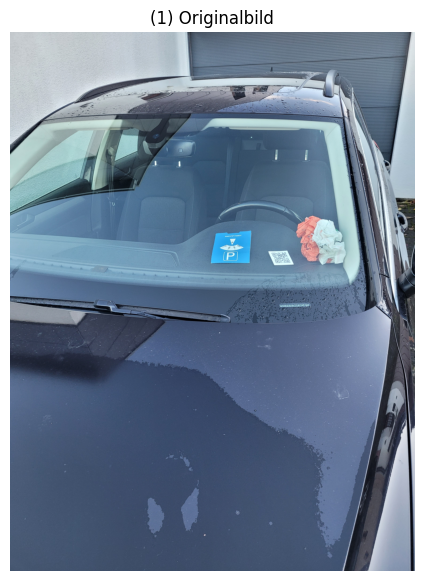

In [5]:
img_path = Path(SELECTED_IMAGE)
img_bgr = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
assert img_bgr is not None, f"Bild konnte nicht geladen werden: {img_path}"

H, W = img_bgr.shape[:2]
print("Image:", img_path.name, "| size:", (W, H))

show(img_bgr, title="(1) Originalbild")


## ROI proposals (C2F) + gelbe Boxen
Diese Zelle erzeugt die ROI-Kandidaten (Patch-Zentren) auf Basis des ROI-Scorings:

- `centers = qr.propose_centers_c2f(img_bgr, roi_cfg)`:
  - führt das Coarse-to-Fine Sliding-Window Scoring aus (Heatmap/ScoreMap intern)
  - liefert Kandidaten-Zentren mit Meta (`cx`, `cy`, `score`, `win`)
- Visualisierung:
  - Für jeden Center wird eine Patch-Box der Größe `patch_size` gezeichnet
  - Farbe **gelb** → “das sind die Kandidaten, die ins CNN gehen”

Output: Originalbild mit gelben ROI-Patch-Boxen.

Proposed centers: 250


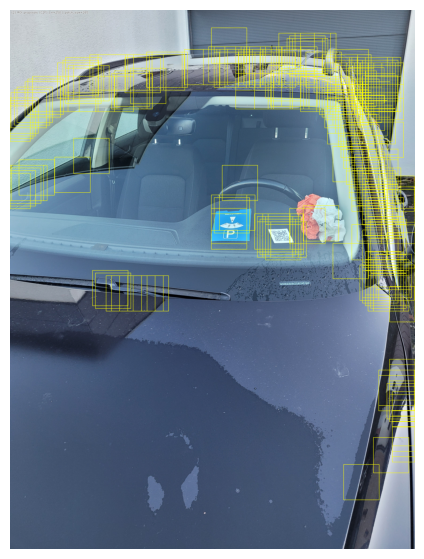

In [6]:
centers = qr.propose_centers_c2f(img_bgr, roi_cfg)
print("Proposed centers:", len(centers))

overlay = img_bgr.copy()
ps = int(roi_cfg.patch_size)
half = ps // 2

for c in centers:
    cx, cy = int(c["cx"]), int(c["cy"])
    x0, y0 = cx - half, cy - half
    x1, y1 = x0 + ps, y0 + ps
    x0, y0, x1, y1 = qr.clamp_box(x0, y0, x1, y1, W, H)
    cv2.rectangle(overlay, (x0, y0), (x1, y1), (0,255,255), 2)

overlay = draw_text_box(overlay, [f"(2) ROI proposals (C2F) | n={len(centers)} | patch_size={ps}"])
show(overlay)



## Patches extrahieren + CNN Inference + Prediction Overlay
Diese Zelle verbindet ROI-Kandidaten mit dem CNN:

1) **Patch-Extraktion**
- Für jedes Zentrum wird ein Patch ausgeschnitten: `qr.pad_and_crop(...)`
- Padding stellt sicher, dass auch ROIs am Rand gültige Patches liefern.

2) **CNN-Inference**
- Batchweise Verarbeitung:
  - Resize auf `loaded.input_size`
  - Normalisierung mit `loaded.mean/std`
  - Forward-Pass durch `loaded.model`
  - Logits → `p` (Probability) via `qr.probs_from_logits`

3) **Outputs**
- Histogramm der Wahrscheinlichkeiten → zeigt, wie gut das Modell trennt
- Overlay auf dem Originalbild:
  - **Grün**: `p >= PATCH_THR`
  - **Rot**: `p < PATCH_THR`
  - `p` wird als Text in die Patch-Box geschrieben

Output: Histogramm + Bild mit farbigen Patch-Predictions.

patch probs: (200,) | min/mean/max: 2.025092316060295e-09 0.0644029825925827 1.0
patch_thr: 0.95 | positives: 10 / 200


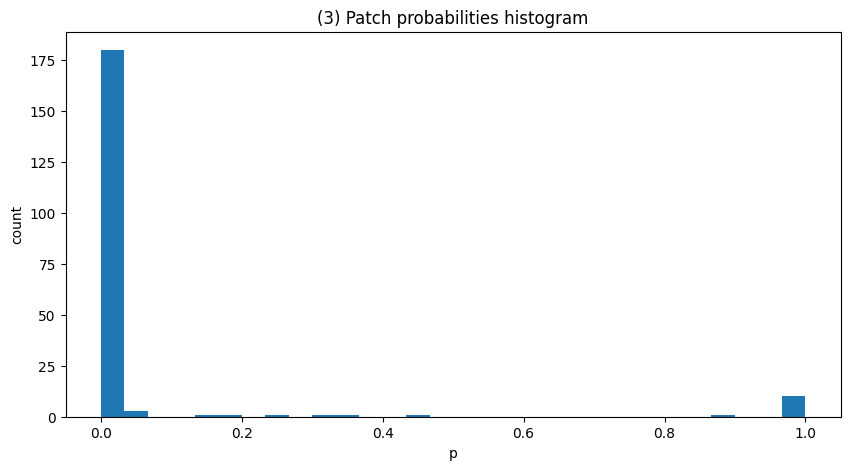

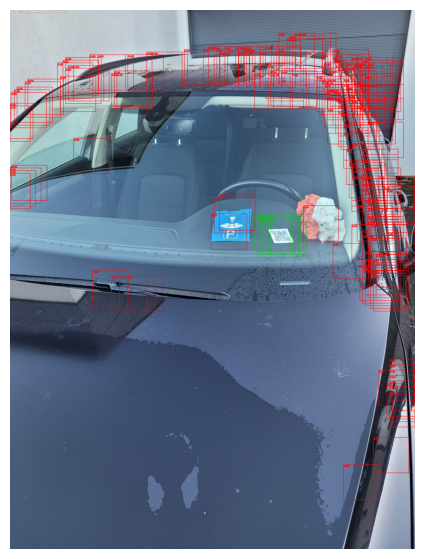

In [7]:
assert torch is not None, "PyTorch fehlt. Installiere torch oder nutze Environment mit torch."

MAX_PATCHES = 200
centers_cap = centers[:MAX_PATCHES]

patches = [qr.pad_and_crop(img_bgr, int(c["cx"]), int(c["cy"]), ps) for c in centers_cap]

BATCH = 64
probs = []
with torch.no_grad():
    for i in range(0, len(patches), BATCH):
        batch = patches[i:i+BATCH]
        x = qr.patches_to_tensor(batch, loaded.input_size, loaded.mean, loaded.std, loaded.device)
        y = loaded.model(x)
        p = qr.probs_from_logits(y)
        probs.extend(list(map(float, p)))

probs = np.array(probs, dtype=np.float32)
print("patch probs:", probs.shape, "| min/mean/max:", float(probs.min()), float(probs.mean()), float(probs.max()))
print("patch_thr:", PATCH_THR, "| positives:", int((probs >= PATCH_THR).sum()), "/", len(probs))

# Histogramm
plt.figure(figsize=(10,5))
plt.hist(probs, bins=30)
plt.title("(3) Patch probabilities histogram")
plt.xlabel("p")
plt.ylabel("count")
plt.show()

# Overlay
view = img_bgr.copy()
for c, p in zip(centers_cap, probs):
    cx, cy = int(c["cx"]), int(c["cy"])
    x0, y0 = cx - half, cy - half
    x1, y1 = x0 + ps, y0 + ps
    x0, y0, x1, y1 = qr.clamp_box(x0, y0, x1, y1, W, H)
    col = (0,200,0) if p >= PATCH_THR else (0,0,255)
    cv2.rectangle(view, (x0,y0), (x1,y1), col, 2)
    cv2.putText(view, f"{p:.2f}", (x0+3, max(18,y0+18)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.55, col, 2, cv2.LINE_AA)

view = draw_text_box(view, [f"(3) CNN patch predictions | thr={PATCH_THR:.2f}"])
show(view)


## Merge via IoU (>= merge_iou) → Merged ROIs + Overlay
Diese Zelle reduziert viele einzelne positive Patches zu wenigen “finalen” ROI-Regionen:

- Filtert nur **positive** Patches (p ≥ thr).
- Baut aus jedem positiven Patch eine Box (patch_size um center).
- `qr.cluster_boxes_by_iou(pos, iou_thr=MERGE_IOU)`:
  - bildet Cluster (Connected Components) basierend auf IoU
  - Ergebnis pro Cluster: Union-Box + Members + Score (z.B. max(p))
- Visualisierung:
  - Jede merged ROI wird als dicke Box gezeichnet (z.B. gelb/cyan)
  - Label zeigt Index, Score und Member-Anzahl

Output: Bild mit merged ROIs (weniger Boxen, größere Regionen).

Positive patches: 10
Merged ROIs: 1 | merge_iou: 0.3


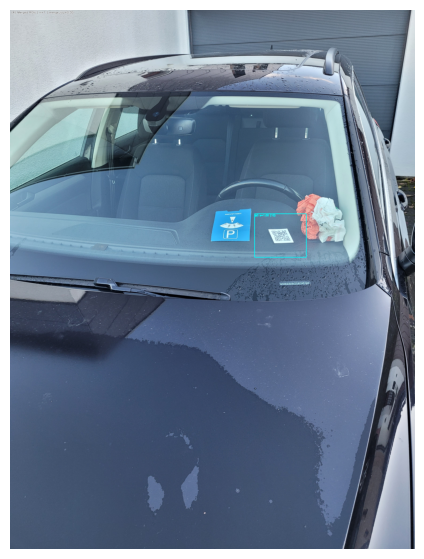

In [8]:
pos = []
for i, (c, p) in enumerate(zip(centers_cap, probs)):
    if p < PATCH_THR:
        continue
    cx, cy = int(c["cx"]), int(c["cy"])
    x0, y0 = cx - half, cy - half
    x1, y1 = x0 + ps, y0 + ps
    x0, y0, x1, y1 = qr.clamp_box(x0, y0, x1, y1, W, H)
    pos.append(qr.PatchBox(idx=i, box=(x0,y0,x1,y1), p=float(p)))

merged = qr.cluster_boxes_by_iou(pos, iou_thr=MERGE_IOU)
print("Positive patches:", len(pos))
print("Merged ROIs:", len(merged), "| merge_iou:", MERGE_IOU)

mview = img_bgr.copy()
for j, m in enumerate(merged):
    x0,y0,x1,y1 = m.box
    cv2.rectangle(mview, (x0,y0), (x1,y1), (255,255,0), 3)
    cv2.putText(mview, f"#{j} s={m.score:.2f} ({len(m.members)})", (x0+3, max(18,y0+18)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,0), 2, cv2.LINE_AA)

mview = draw_text_box(mview, [f"(4) Merged ROIs | n={len(merged)} | merge_iou={MERGE_IOU:.2f}"])
show(mview)


## ROI auswählen + Crop (pad) + Plan A (OpenCV corners)
Hier beginnt die Rectification/Corner-Detektion:

- Wählt eine merged ROI per Index (`SELECTED_MERGED_IDX`).
- Erweitert die Union-Box mit `qr.expand_box(..., pad_frac=ROI_PAD_FRAC)`:
  - wichtig für quiet zone / Rand
- Croppt das Bild auf diese Box.
- **Plan A**:
  - `qr.detect_qr_corners_opencv(det, crop)` nutzt OpenCV QRCodeDetector
  - Falls Ecken gefunden: Quad wird grün eingezeichnet

Output: Crop-Bild mit Plan-A-Ecken (oder “no corners”).

Selected merged: 0 | score: 1.0 | members: 10
union box: (1826, 1524, 2212, 1849)
crop box : (1749, 1459, 2289, 1914)


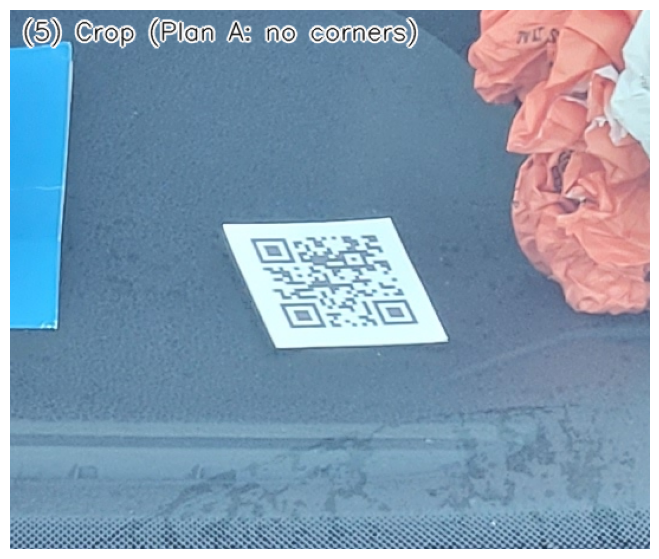

In [9]:
det = cv2.QRCodeDetector()

SELECTED_MERGED_IDX = 0
if len(merged) == 0:
    raise RuntimeError("Keine merged ROIs gefunden. (thr zu hoch? iou zu niedrig?)")

mi = int(np.clip(SELECTED_MERGED_IDX, 0, len(merged)-1))
m = merged[mi]

cb = qr.expand_box(m.box, pad_frac=ROI_PAD_FRAC, w=W, h=H)
cr = qr.crop_bgr(img_bgr, cb)

print("Selected merged:", mi, "| score:", m.score, "| members:", len(m.members))
print("union box:", m.box)
print("crop box :", cb)

qA = qr.detect_qr_corners_opencv(det, cr)

cr_vis = cr.copy()
if qA is not None:
    qr.draw_poly(cr_vis, qA, color=(0,255,0), thickness=3)
    cr_vis = draw_text_box(cr_vis, ["(5) Crop + Plan A corners (green)"])
else:
    cr_vis = draw_text_box(cr_vis, ["(5) Crop (Plan A: no corners)"])

show(cr_vis)


## Plan B V4 Preprocessing (otsu, k=3, close=4, open=0) mit Zwischenoutputs
Diese Zelle macht Plan B transparent, bevor Quad-Fit passiert:

- `qr.preprocess_variants(crop)` erzeugt mehrere binäre Kandidaten:
  - `edges`, `adap`, `otsu`, `otsu_inv`
- Default wird `otsu` gewählt (Plan B default aus Screenshot).
- `qr.maybe_fix_polarity(...)` korrigiert ggf. Foreground/Background (falls invertiert).
- Morphologie:
  - **CLOSE** (`cv2.MORPH_CLOSE`) mit `k=3`, `close=4`:
    - schließt kleine Lücken, verbindet unterbrochene QR-Strukturen
  - **OPEN** (`cv2.MORPH_OPEN`) mit `open=0`:
    - optionales Entfernen kleiner Noise-Inseln (hier deaktiviert)
- `used = qr.binarize(...)` erzeugt die finale binäre Maske für Plan B.

Outputs:
- RAW (nach Variant + Polarity Fix)
- nach CLOSE
- nach OPEN
- USED (final für Plan B)

PlanB variant: otsu | k: 3 | close: 4 | open: 0


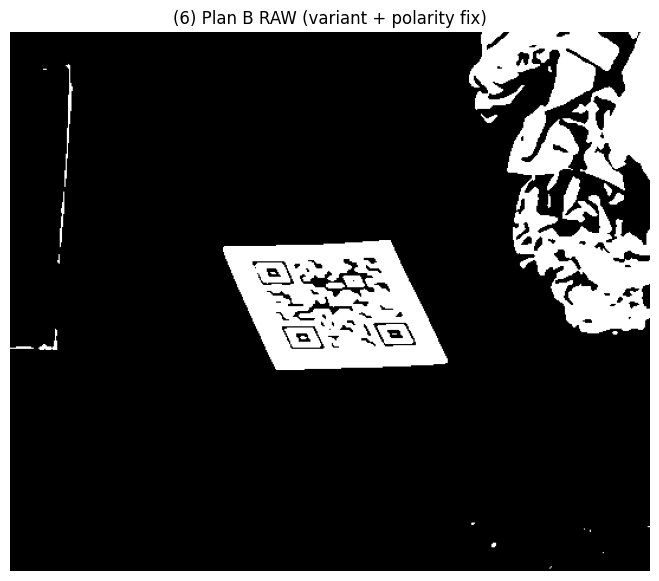

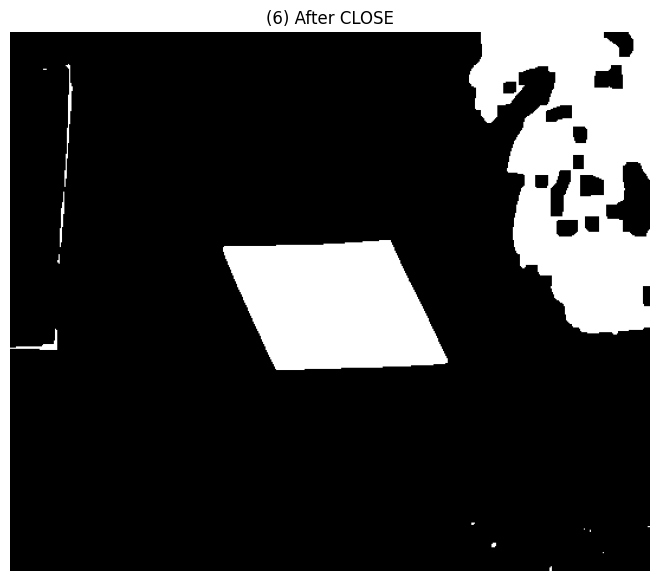

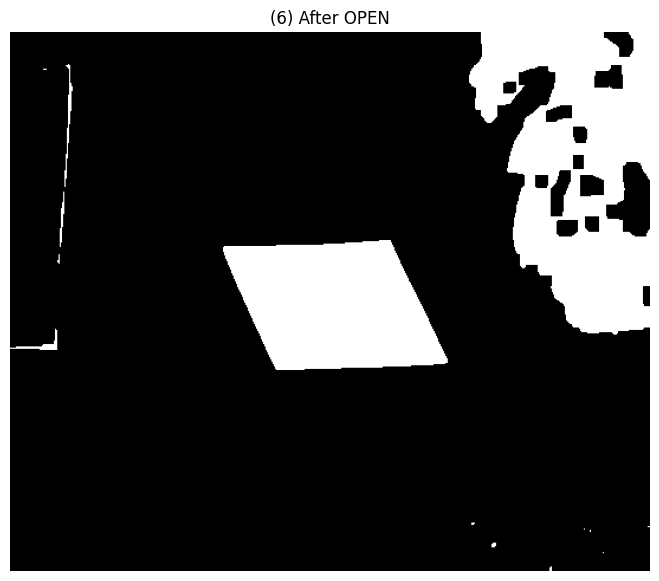

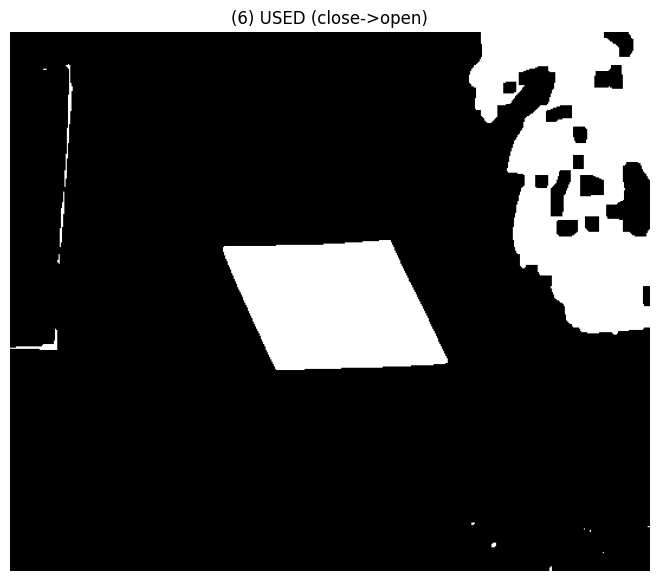

In [10]:
PLANB_VARIANT = DEFAULT_PLANB_VARIANT
PLANB_K = DEFAULT_PLANB_K
PLANB_CLOSE = DEFAULT_PLANB_CLOSE
PLANB_OPEN = DEFAULT_PLANB_OPEN

vars_ = qr.preprocess_variants(cr)
raw0 = vars_.get(PLANB_VARIANT, vars_["otsu"])
raw = qr.maybe_fix_polarity(raw0)

k = qr._ensure_odd(PLANB_K)
close_img = qr.morph(raw, cv2.MORPH_CLOSE, k, PLANB_CLOSE)
open_img  = qr.morph(close_img, cv2.MORPH_OPEN,  k, PLANB_OPEN)
used = qr.binarize(open_img)

print("PlanB variant:", PLANB_VARIANT, "| k:", k, "| close:", PLANB_CLOSE, "| open:", PLANB_OPEN)

show_gray(raw, title="(6) Plan B RAW (variant + polarity fix)")
show_gray(qr.binarize(close_img), title="(6) After CLOSE")
show_gray(qr.binarize(open_img), title="(6) After OPEN")
show_gray(used, title="(6) USED (close->open)")


## Plan B V4: Quad-Fit Debug-Grid + Warp + quick decode
Diese Zelle führt Plan B komplett aus und zeigt alles, was beim Quad-Fit passiert:

- `dbg = qr.planb_v4(crop, ...)` liefert ein Debug-Objekt mit:
  - `raw/close/open/used`
  - `obj_mask` (Maskenentscheidung: edge-like vs filled)
  - `edges_boundary` (Boundary der Maske)
  - `contour` (beste Kontur)
  - `quad` (finaler 4-Punkt-Polygon-Fit)
  - `quad_iou` (Qualitätsmaß: Quad vs Mask overlap)
- Debug-Grid:
  - Crop mit Contour/Quad
  - RAW/CLOSE/OPEN/USED
  - OBJ_MASK
  - EDGES boundary
  - Quad overlay
- Wenn Quad existiert:
  - Quad wird von Crop-Koordinaten auf Full-Image gemappt (Offset addieren)
  - `qr.warp_quad_to_square(...)` erzeugt den entzerrten (rectified) QR-Ausschnitt
  - Optional: `det.detectAndDecode(warp)` als schneller Test

Outputs:
- Debug-Grid
- Warp-Bild mit IoU und Decode-Status

PlanB ok: True
PlanB note: OK | filled | approxPolyDP(use_hull=0) eps=0.007 iou=38.09%
Quad IoU vs obj_mask: 38.09%


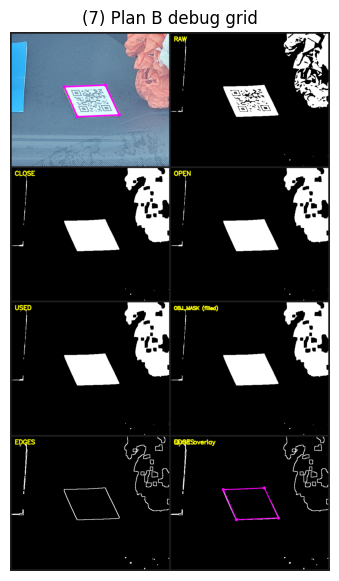

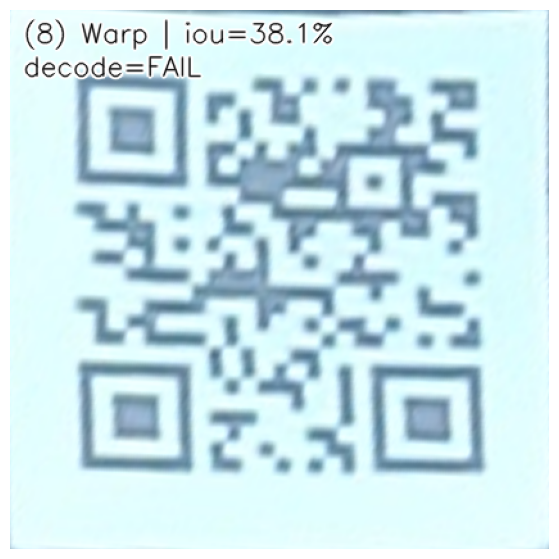

In [11]:
dbg = qr.planb_v4(
    crop_bgr_img=cr,
    variant=PLANB_VARIANT,
    k=PLANB_K,
    close_it=PLANB_CLOSE,
    open_it=PLANB_OPEN,
)

print("PlanB ok:", dbg.ok)
print("PlanB note:", dbg.note)
print("Quad IoU vs obj_mask:", f"{dbg.quad_iou*100:.2f}%")

# Debug grid
cr_vis = cr.copy()
if dbg.contour is not None:
    cv2.drawContours(cr_vis, [dbg.contour], -1, (0,255,255), 2, cv2.LINE_AA)
if dbg.ok and dbg.quad is not None:
    qr.draw_poly(cr_vis, dbg.quad, color=(255,0,255), thickness=3)

p_raw  = qr.gray_to_bgr(dbg.raw)
p_cl   = qr.gray_to_bgr(qr.binarize(dbg.close_img))
p_op   = qr.gray_to_bgr(qr.binarize(dbg.open_img))
p_used = qr.gray_to_bgr(dbg.used)
p_mask = qr.gray_to_bgr(dbg.obj_mask)
p_edges = qr.gray_to_bgr(dbg.edges_boundary)

cv2.putText(p_raw,  "RAW",  (10,25), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,255,255), 2, cv2.LINE_AA)
cv2.putText(p_cl,   "CLOSE",(10,25), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,255,255), 2, cv2.LINE_AA)
cv2.putText(p_op,   "OPEN", (10,25), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,255,255), 2, cv2.LINE_AA)
cv2.putText(p_used, "USED", (10,25), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,255,255), 2, cv2.LINE_AA)
cv2.putText(p_mask, f"OBJ_MASK ({'edge->fill' if dbg.edge_like else 'filled'})", (10,25),
            cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0,255,255), 2, cv2.LINE_AA)
cv2.putText(p_edges, "EDGES", (10,25), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,255,255), 2, cv2.LINE_AA)

overlay = p_edges.copy()
if dbg.ok and dbg.quad is not None:
    qr.draw_poly(overlay, dbg.quad, color=(255,0,255), thickness=2)
cv2.putText(overlay, "Quad overlay", (10,25), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,255,255), 2, cv2.LINE_AA)

grid = qr.make_grid([cr_vis, p_raw, p_cl, p_op, p_used, p_mask, p_edges, overlay], cols=2)
show(grid, title="(7) Plan B debug grid")

# Warp (wenn Quad existiert)
if dbg.ok and dbg.quad is not None:
    quad_full = dbg.quad.copy()
    quad_full[:, 0] += cb[0]
    quad_full[:, 1] += cb[1]

    warp = qr.warp_quad_to_square(img_bgr, quad_full, out_size=420)

    # quick decode
    txt, _, _ = det.detectAndDecode(warp)
    warp = draw_text_box(warp, [f"(8) Warp | iou={dbg.quad_iou*100:.1f}%",
                                f"decode={'OK' if txt else 'FAIL'}",
                                (txt[:40] if txt else "")])
    show(warp)
else:
    print("Kein Quad -> kein Warp.")


## Ranking: Top-N ROIs (Plan A vs Plan B + decode preview)
Diese Zelle bewertet mehrere merged ROIs automatisiert und erstellt eine Übersicht:

- Für `TOPN` ROIs:
  - Crop mit Pad
  - Plan A: corners vorhanden?
  - Plan B: Quad vorhanden + `quad_iou_%`
  - Falls Plan B Quad: Warp und kurzer Decode-Preview (`decode_warp`)
- Ergebnis wird als `rows` gesammelt.
- Wenn `pandas` verfügbar:
  - DataFrame erzeugen und sortieren:
    - `planB_ok` zuerst, dann `planB_iou_%`, dann `roi_score`
  - `display(df)` zeigt eine Ranking-Tabelle
- Ohne pandas: dicts ausgeben.

Output: Tabelle, die dir schnell zeigt, welche ROI am besten rectified/decodable ist.

In [12]:
if len(merged) == 0:
    raise RuntimeError("Keine merged ROIs -> Ranking nicht möglich.")

TOPN = min(10, len(merged))
rows = []
det = cv2.QRCodeDetector()

for j in range(TOPN):
    m = merged[j]
    cb_j = qr.expand_box(m.box, pad_frac=ROI_PAD_FRAC, w=W, h=H)
    cr_j = qr.crop_bgr(img_bgr, cb_j)

    qA = qr.detect_qr_corners_opencv(det, cr_j)
    okA = qA is not None

    dbg_j = qr.planb_v4(
        cr_j,
        variant=DEFAULT_PLANB_VARIANT,
        k=DEFAULT_PLANB_K,
        close_it=DEFAULT_PLANB_CLOSE,
        open_it=DEFAULT_PLANB_OPEN
    )
    okB = bool(dbg_j.ok and dbg_j.quad is not None)

    dec = ""
    if okB:
        qf = dbg_j.quad.copy()
        qf[:, 0] += cb_j[0]
        qf[:, 1] += cb_j[1]
        wimg = qr.warp_quad_to_square(img_bgr, qf, out_size=420)
        t, _, _ = det.detectAndDecode(wimg)
        dec = t[:40] if t else ""

    rows.append({
        "roi_idx": j,
        "roi_score": float(m.score),
        "members": len(m.members),
        "planA_ok": okA,
        "planB_ok": okB,
        "planB_iou_%": float(dbg_j.quad_iou * 100.0),
        "decode_warp": dec
    })

if pd is not None:
    df = pd.DataFrame(rows).sort_values(["planB_ok", "planB_iou_%", "roi_score"], ascending=False)
    display(df)
else:
    for r in rows:
        print(r)

print("Done.")


{'roi_idx': 0, 'roi_score': 1.0, 'members': 10, 'planA_ok': False, 'planB_ok': True, 'planB_iou_%': 38.09499823704226, 'decode_warp': ''}
Done.


## Rotation um X/Y/Z aus dem gefundenen Quad (Heuristik)

### Idee / Heuristik (robust, ohne Kamerakalibrierung)
1) **rot_z** wird über die obere Kante `TL→TR` berechnet (`atan2`).
2) Dann wird das Quad um `-rot_z` **entdreht**, damit „oben/unten“ und „links/rechts“ wirklich axial liegen.
3) **rot_x** wird aus dem Verhältnis der Kantenlängen `top vs bottom` geschätzt:
   - perspektivisch erscheint die nähere Seite länger → `min/max ≈ cos(rot_x)`
4) **rot_y** analog aus `left vs right`.


In [14]:
import math
import numpy as np
import cv2

def clamp01(x: float) -> float:
    return max(0.0, min(1.0, float(x)))

def side_lengths(quad: np.ndarray):
    """
    quad: (4,2) in Reihenfolge TL, TR, BR, BL
    returns: top, right, bottom, left (float)
    """
    tl, tr, br, bl = np.asarray(quad, dtype=np.float32).reshape(4, 2)
    top = float(np.linalg.norm(tr - tl))
    right = float(np.linalg.norm(br - tr))
    bottom = float(np.linalg.norm(br - bl))
    left = float(np.linalg.norm(bl - tl))
    return top, right, bottom, left

def estimate_rot_z_deg_from_quad(quad: np.ndarray) -> float:
    """
    In-plane Rotation (um Z): Winkel der oberen Kante TL->TR relativ zur X-Achse.
    Bildkoordinaten: +x rechts, +y unten.
    Für "mathematische" CCW-Konvention (y nach oben) verwenden wir -dy.
    """
    tl, tr, br, bl = np.asarray(quad, dtype=np.float32).reshape(4, 2)
    dx = float(tr[0] - tl[0])
    dy = float(tr[1] - tl[1])
    ang = math.degrees(math.atan2(-dy, dx))  # -dy => y-up, CCW positiv
    # normalisieren auf [-180, 180)
    if ang >= 180.0:
        ang -= 360.0
    if ang < -180.0:
        ang += 360.0
    return ang

def rotate_quad_2d_about_center(quad: np.ndarray, angle_deg: float) -> np.ndarray:
    """
    Rotiert Quad in der Bildebene um seinen Schwerpunkt.
    angle_deg in gleicher Konvention wie estimate_rot_z_deg_from_quad (y-up, CCW).
    """
    q = np.asarray(quad, dtype=np.float32).reshape(4, 2)
    c = q.mean(axis=0)

    a = math.radians(float(angle_deg))
    ca, sa = math.cos(a), math.sin(a)

    # rotate in y-up coords
    x = q[:, 0] - c[0]
    y_up = -(q[:, 1] - c[1])      # y-down -> y-up

    xr = ca * x - sa * y_up
    yr_up = sa * x + ca * y_up

    # back to y-down
    yr = -yr_up
    return np.stack([xr + c[0], yr + c[1]], axis=1).astype(np.float32)

def estimate_rot_xy_deg_from_quad(quad: np.ndarray):
    """
    Perspektiv-Heuristik (nach Entdrehen um rot_z!):
    - rot_x aus top vs bottom
    - rot_y aus left vs right
    Sign wird über "welche Seite ist länger" gesetzt.
    """
    top, right, bottom, left = side_lengths(quad)

    r_tb = min(top, bottom) / (max(top, bottom) + 1e-6)   # ~ cos(rot_x)
    rot_x = math.degrees(math.acos(clamp01(r_tb)))

    r_lr = min(left, right) / (max(left, right) + 1e-6)   # ~ cos(rot_y)
    rot_y = math.degrees(math.acos(clamp01(r_lr)))

    # Vorzeichen: welche Seite ist näher/größer?
    rot_x *= 1.0 if (bottom > top) else -1.0
    rot_y *= 1.0 if (right > left) else -1.0
    return rot_x, rot_y

def estimate_rot_xyz_deg_from_quad(quad_full: np.ndarray):
    """
    Gesamt: (rot_x, rot_y, rot_z)
    1) rot_z aus TL->TR
    2) quad um -rot_z entdrehen
    3) rot_x/rot_y aus Kantenlängen-Verhältnissen
    """
    rz = estimate_rot_z_deg_from_quad(quad_full)
    q0 = rotate_quad_2d_about_center(quad_full, -rz)   # entdrehen
    rx, ry = estimate_rot_xy_deg_from_quad(q0)
    return rx, ry, rz, q0

def draw_quad_with_angles(img_bgr: np.ndarray, quad: np.ndarray, rx: float, ry: float, rz: float, title=""):
    """
    Debug-Overlay: zeichnet Quad + Textblock.
    """
    vis = img_bgr.copy()
    q = np.asarray(quad, dtype=np.int32).reshape(4,2)
    cv2.polylines(vis, [q], isClosed=True, color=(255, 0, 255), thickness=3, lineType=cv2.LINE_AA)
    tl, tr, br, bl = q
    cv2.circle(vis, tuple(tl), 6, (0,255,255), -1)
    cv2.putText(vis, "TL", tuple(tl + np.array([8, -8])), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,255,255), 2, cv2.LINE_AA)

    lines = [
        title,
        f"rot_x (tilt) : {rx:+.2f} deg",
        f"rot_y (tilt) : {ry:+.2f} deg",
        f"rot_z (inplane): {rz:+.2f} deg",
    ]
    y = 30
    for s in lines:
        if not s:
            continue
        cv2.putText(vis, s, (20, y), cv2.FONT_HERSHEY_SIMPLEX, 0.75, (0,255,255), 2, cv2.LINE_AA)
        y += 28
    return vis


# =========================
# Anwendung 1: direkt nach deinem PlanB/Warp-Block
# (da existiert quad_full bereits, wenn PlanB ok ist)
# =========================
if "quad_full" in globals() and quad_full is not None:
    rx, ry, rz, quad_derot = estimate_rot_xyz_deg_from_quad(quad_full)
    print(f"[XYZ] rot_x={rx:+.2f}°, rot_y={ry:+.2f}°, rot_z={rz:+.2f}°")

    # optional: Seitenlängen vor/nach Entdrehen
    top, right, bottom, left = side_lengths(quad_full)
    top0, right0, bottom0, left0 = side_lengths(quad_derot)
    print(f"Sides orig     : top={top:.1f}, right={right:.1f}, bottom={bottom:.1f}, left={left:.1f}")
    print(f"Sides -rot_z   : top={top0:.1f}, right={right0:.1f}, bottom={bottom0:.1f}, left={left0:.1f}")

    # Overlay auf Originalbild
    vis = draw_quad_with_angles(img_bgr, quad_full, rx, ry, rz, title="(9) Quad + XYZ rotation")
    # show(vis, title="(9) Rotation debug overlay")
else:
    print("quad_full ist nicht gesetzt/None. PlanB muss ok sein, damit ein Quad existiert.")


[XYZ] rot_x=+11.71°, rot_y=+8.45°, rot_z=+2.44°
Sides orig     : top=141.1, right=113.6, bottom=144.1, left=112.4
Sides -rot_z   : top=141.1, right=113.6, bottom=144.1, left=112.4
